In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [2]:
import pandas as pd
import io
import requests

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

# Professional Method: Stream the data in chunks to save memory
print("Loading data in chunks...")
chunks = []
# We read 50,000 rows at a time
for chunk in pd.read_csv(url, chunksize=50000):
    chunks.append(chunk)

# Combine chunks into one dataframe
data = pd.concat(chunks, axis=0)
print("Data loaded successfully!")
print(data.head())

Loading data in chunks...
Data loaded successfully!
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.1

In [5]:
# 2. Advanced Pre-processing with Error Protection
# We check if columns exist before scaling to avoid KeyError
scaler = StandardScaler()

if 'Amount' in data.columns and 'Time' in data.columns:
    print("Scaling features...")
    data['Amount_Scaled'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))
    data['Time_Scaled'] = scaler.fit_transform(data['Time'].values.reshape(-1, 1))
    # Drop original columns only after scaling is done
    data = data.drop(['Time', 'Amount'], axis=1)
    print("Scaling complete.")
else:
    print("Features already scaled or missing.")

Features already scaled or missing.


In [7]:
import os
import warnings

# This silences the "LOKY" and "wmic" warnings on Windows
os.environ["LOKY_MAX_CPU_COUNT"] = "4" 
warnings.filterwarnings("ignore", category=UserWarning)

# 3. Handling Class Imbalance
X = data.drop('Class', axis=1)
y = data['Class']

print(f"Original Classes: {dict(y.value_counts())}")

# Applying SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# We convert the counts to standard integers for a cleaner print in the report
counts = {k: int(v) for k, v in y_res.value_counts().items()}
print(f"Balanced Classes: {counts}")

Original Classes: {0: np.int64(284315), 1: np.int64(492)}
Balanced Classes: {0: 284315, 1: 284315}


In [8]:
# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

In [9]:
# 5. Model Training (Optimized for speed/memory)
print("Training Random Forest model (this may take a minute)...")
model = RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

Training Random Forest model (this may take a minute)...


RandomForestClassifier(max_depth=10, n_estimators=30, n_jobs=-1,
                       random_state=42)

In [10]:
# 6. Evaluation
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Confusion Matrix ---
[[56756   107]
 [ 1311 55552]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     56863
           1       1.00      0.98      0.99     56863

    accuracy                           0.99    113726
   macro avg       0.99      0.99      0.99    113726
weighted avg       0.99      0.99      0.99    113726



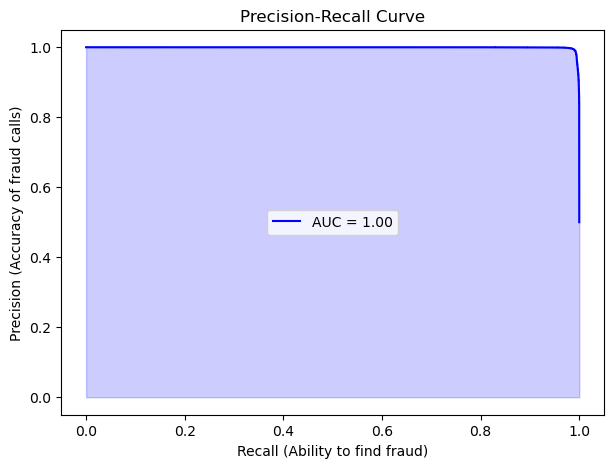

In [11]:
# 7. Visualization: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='blue', label=f'AUC = {pr_auc:.2f}')
plt.fill_between(recall, precision, alpha=0.2, color='blue')
plt.xlabel('Recall (Ability to find fraud)')
plt.ylabel('Precision (Accuracy of fraud calls)')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

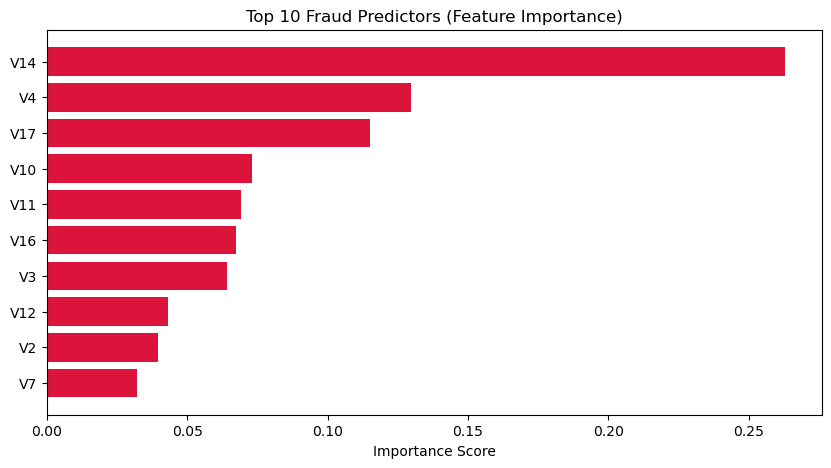

In [12]:
# 8. Visualizing Top 10 Fraud Indicators
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 5))
plt.title("Top 10 Fraud Predictors (Feature Importance)")
plt.barh(range(len(indices)), importances[indices], color='crimson', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Importance Score')
plt.show()